In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [3]:
pred_500 = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/predicted_k562_regulator_knockout_gosai.csv")

In [4]:
pred_500['allele'] = pred_500['motif_name'].str.extract(r"_(ref|alt)")
pred_500['motif_group'] = pred_500['motif_name'].str.replace(r'_alt$', '', regex=True)
merged_df_ref = pred_500[pred_500['allele'] != 'alt'].copy()
merged_df_alt = pred_500[pred_500['allele'] == 'alt'].copy()


merged_df_ref = merged_df_ref.rename(columns={col: f"ref_{col}" for col in merged_df_ref.columns if col not in ['seq_id', 'motif_group', 'motif_name']})
merged_df_alt = merged_df_alt.rename(columns={col: f"alt_{col}" for col in merged_df_alt.columns if col not in ['seq_id', 'motif_group', 'motif_name']})

merged_df = pd.merge(merged_df_ref, merged_df_alt, on=['seq_id', 'motif_group'], how='inner')

offsets=range(-80,81)

# Compute diff_offset for each offset
for offset in offsets:
    merged_df[f'diff_{offset}'] =  merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']

avg_diff = merged_df.groupby('motif_group')[[f'diff_{offset}' for offset in offsets]].mean().reset_index()


/tmp/ipykernel_1491487/3955159958.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df[f'diff_{offset}'] =  merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']
/tmp/ipykernel_1491487/3955159958.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df[f'diff_{offset}'] =  merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']
/tmp/ipykernel_1491487/3955159958.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert`

In [5]:
# Update column names based on the value after diff_
updated_columns = []

for col in avg_diff.columns:
    if col.startswith("diff_"):  # Check if the column name starts with "diff_"
        value = int(col.split("_")[1])  # Extract the value after diff_
        if value < 0:
            updated_columns.append(f"{-value}")  # Append "right" for negative values
        elif value > 0:
            updated_columns.append(f"{-value}")  # Append "left" for positive values
        else:
            updated_columns.append(f"{value}")  # Append "center" for zero values
    else:
        updated_columns.append(col)  # Keep the motif_group column unchanged



# Assign the new column names back to the DataFrame
avg_diff.columns = updated_columns

# Print the updated column names to check
print(avg_diff.columns)


Index(['motif_group', '80', '79', '78', '77', '76', '75', '74', '73', '72',
       ...
       '-71', '-72', '-73', '-74', '-75', '-76', '-77', '-78', '-79', '-80'],
      dtype='object', length=162)


In [6]:
pos_cols = [col for col in avg_diff.columns if col != 'motif_group']

# Convert the position columns to integers for sorting
pos_cols_int = [int(c) for c in pos_cols]

# Sort numerically from -80 to 80
pos_cols_sorted = sorted(pos_cols_int)

# Convert back to string because your columns are strings
pos_cols_sorted_str = [str(c) for c in pos_cols_sorted]

# Reorder columns with 'motif_group' first, then sorted positions
new_col_order = ['motif_group'] + pos_cols_sorted_str

# Reindex the dataframe columns
avg_diff = avg_diff[new_col_order]

# Check
print(avg_diff.columns)

Index(['motif_group', '-80', '-79', '-78', '-77', '-76', '-75', '-74', '-73',
       '-72',
       ...
       '71', '72', '73', '74', '75', '76', '77', '78', '79', '80'],
      dtype='object', length=162)


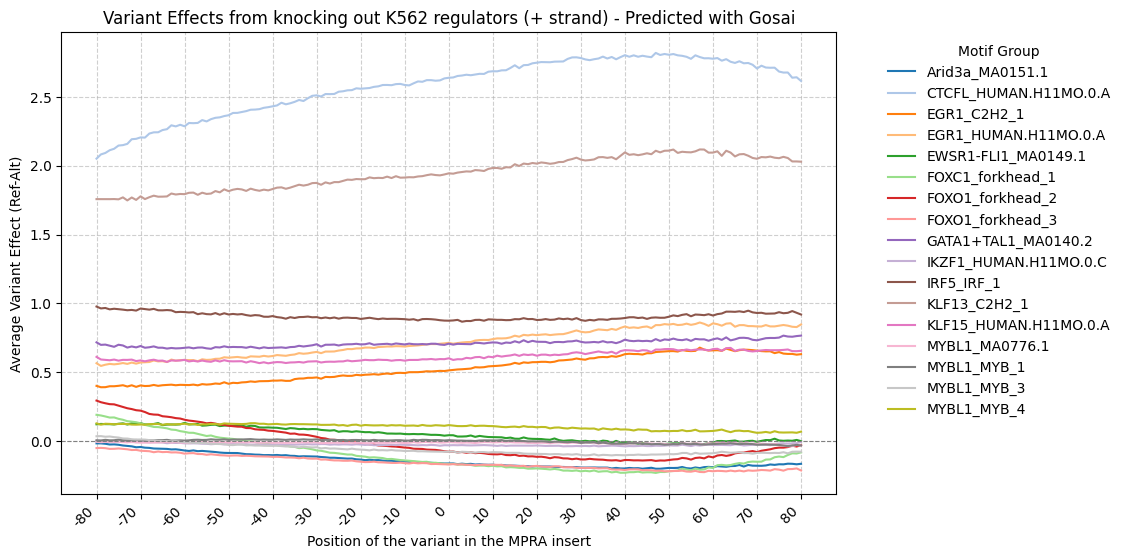

In [7]:
# Filter out Mouse-related motif groups
avg_diff = avg_diff[~avg_diff['motif_group'].str.contains("Mouse", case=False, na=False)]

offsets = range(-80,81)
mapped_offsets = offsets  # No transformation applied

# Generate distinct colors
num_motifs = avg_diff.shape[0]
colormap = plt.get_cmap("tab20")  # Use plt.get_cmap instead of cm.get_cmap
colors = [colormap(i % 20) for i in range(num_motifs)]  # Ensure we don't exceed 20 colors

# Plot
plt.figure(figsize=(10, 6))

x_labels = avg_diff.columns[1:]  # Skip 'motif_group'
x_vals = range(len(x_labels))    # Use their index positions for plotting

for idx, (_, row) in enumerate(avg_diff.iterrows()):
    y_vals = row[1:]  
    plt.plot(x_vals, y_vals, label=row['motif_group'], color=colors[idx])

# Formatting
plt.xlabel("Position of the variant in the MPRA insert")
plt.ylabel("Average Variant Effect (Ref-Alt)")
tick_indices = list(range(0, len(x_labels), 10))
tick_labels = [x_labels[i] for i in tick_indices]
plt.xticks(ticks=tick_indices, labels=tick_labels, rotation=45, ha="right")

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)  # Add horizontal reference line
plt.legend(title="Motif Group", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.title("Variant Effects from knocking out K562 regulators (+ strand) - Predicted with Gosai")
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/knockout.svg", format="svg")

# Show plot
plt.show()


In [8]:
avg_diff.head(2)

,motif_group,-80,-79,-78,-77,-76,-75,-74,-73,-72,...,71,72,73,74,75,76,77,78,79,80
0,Arid3a_MA0151.1,-0.014921,-0.014819,-0.017711,-0.023028,-0.021951,-0.024845,-0.030220,-0.033528,-0.036312,...,-0.177444,-0.175033,-0.167814,-0.170680,-0.166375,-0.166937,-0.162134,-0.163031,-0.166567,-0.162843
1,CTCFL_HUMAN.H11MO.0.A,2.050215,2.080886,2.091297,2.111269,2.121884,2.145185,2.148235,2.157477,2.191128,...,2.724334,2.711067,2.709469,2.709894,2.681818,2.674550,2.675014,2.637279,2.640381,2.613617


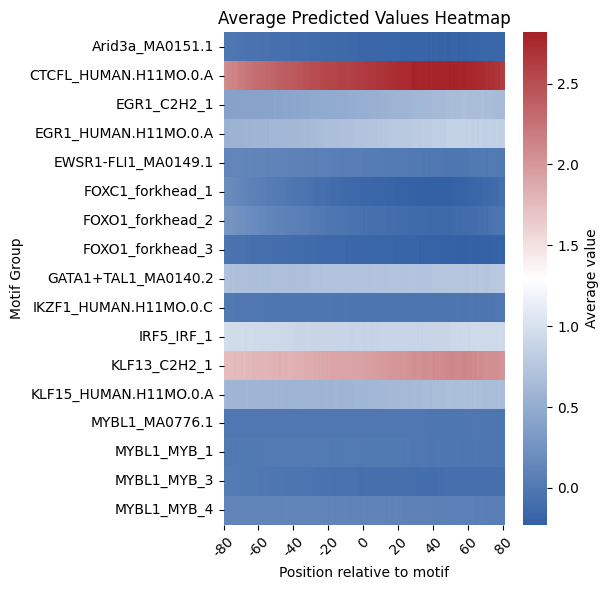

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Positions as integers for x labels
position_cols = [col for col in avg_diff.columns if col != 'motif_group']

# Convert to int
positions = list(map(int, position_cols))

# Choose every 20th position for x-ticks
xticks_positions = np.arange(-80, 81, 20)
xticks_indices = [np.where(positions == pos)[0][0] for pos in xticks_positions if pos in positions]
colors = ['#3361A5', '#ffffff', '#A52126']
cmap = LinearSegmentedColormap.from_list('custom_blue_white_red', colors, N=256)

motif_filter = ["CTCFL", "GATA1", "FOXO1", "EGR1"]
y_labels = list(avg_diff['motif_group'])


plt.figure(figsize=(6, max(6, len(avg_diff)*0.15)))

sns.heatmap(
    avg_diff[position_cols],
    cmap=cmap,
    yticklabels=y_labels,
    xticklabels=False,  # turn off default x labels for now
    cbar_kws={"label": "Average value"},
)

plt.xlabel("Position relative to motif")
plt.ylabel("Motif Group")
plt.title("Average Predicted Values Heatmap")

# Set x ticks and labels every 20 positions
plt.xticks(xticks_indices, xticks_positions, rotation=45)

plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/knockout_heatmap_uneditted_rc.png", dpi=300)

plt.show()


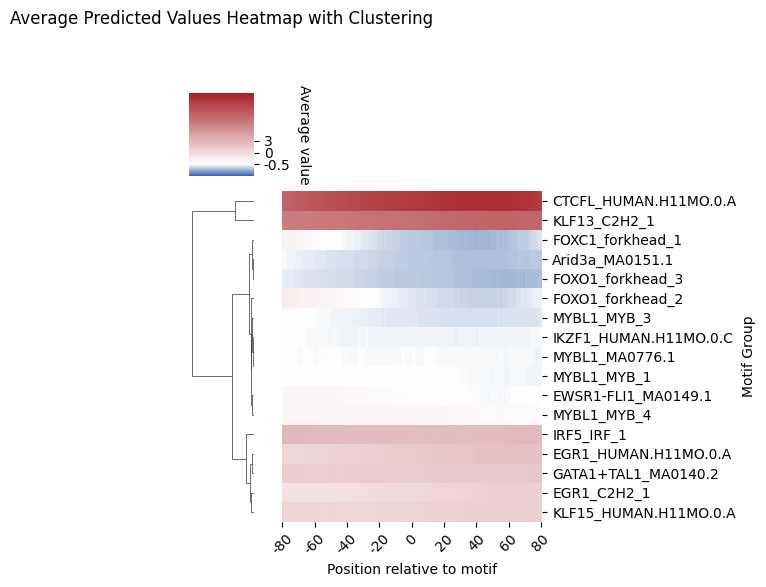

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Positions as integers for x labels
position_cols = [col for col in avg_diff.columns if col != 'motif_group']
positions = np.array(list(map(int, position_cols)))
xticks_positions = np.arange(-80, 81, 20)
xticks_indices = [np.where(positions == pos)[0][0] for pos in xticks_positions if pos in positions]

# Custom colormap with white at 0
vmin, vmax = -0.5, 3
white_pos = -vmin / (vmax - vmin)
colors = [(0.0, "#3361A5"), (white_pos, "#ffffff"), (1.0, "#A52126")]
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", colors)

# Full data matrix
data_matrix = avg_diff.set_index('motif_group')[position_cols]

# Plot clustermap with row clustering
g = sns.clustermap(
    data_matrix,
    cmap=cmap,
    row_cluster=True,
    col_cluster=False,        # keep positions in original order
    figsize=(6, max(6, len(data_matrix) * 0.75 * 0.15)),
    yticklabels=True,
    xticklabels=False,
    vmin=vmin,
    vmax=vmax,
)

# Set x-axis ticks manually
g.ax_heatmap.set_xticks(xticks_indices)
g.ax_heatmap.set_xticklabels(xticks_positions, rotation=45)

g.ax_heatmap.set_xlabel("Position relative to motif")
g.ax_heatmap.set_ylabel("Motif Group")
plt.title("Average Predicted Values Heatmap with Clustering", pad=50)

# Adjust colorbar ticks to show min, zero, max
cbar = g.cax
cbar_ticks = [-0.5, 0, 3]
g.cax.set_yticks([0, 0.5, 1])  # placeholder, will be adjusted by colorbar
g.cax.set_yticklabels(cbar_ticks)
g.cax.set_ylabel("Average value", rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/knockout_clustermap_full.png",
    dpi=600
)
plt.show()


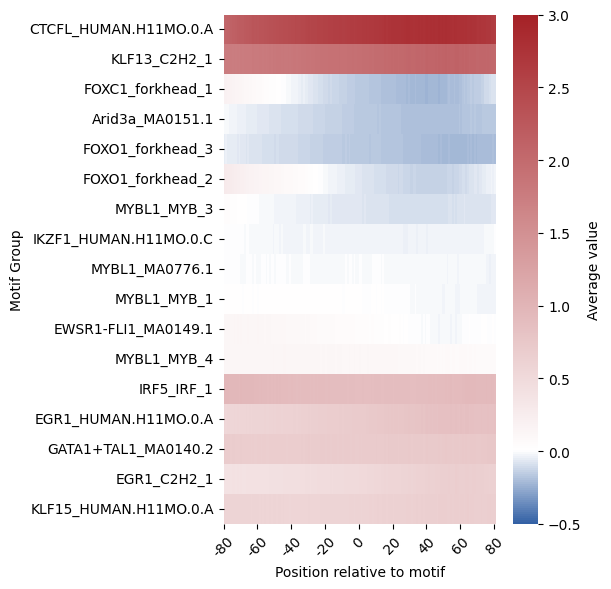

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list

# Positions as integers for x labels
position_cols = [col for col in avg_diff.columns if col != 'motif_group']

# Convert to int
positions = np.array(list(map(int, position_cols)))

# Choose every 20th position for x-ticks
xticks_positions = np.arange(-80, 81, 20)
xticks_indices = [np.where(positions == pos)[0][0] for pos in xticks_positions if pos in positions]

# Custom colormap: blue → white → red
from matplotlib.colors import LinearSegmentedColormap

# Relative position of 0 in the range
vmin, vmax = -0.5, 3
white_pos = -vmin / (vmax - vmin)  # fraction along 0-1 scale

colors = [
    (0.0, "#3361A5"),       # start blue
    (white_pos, "#ffffff"), # white at 0
    (1.0, "#A52126")        # end red
]

# Create segmented colormap
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", colors)


# Filter motifs (if needed)
motif_filter = ["CTCFL", "GATA1", "FOXO1", "EGR1"]
y_labels = list(avg_diff['motif_group'])

# 1. Reduce per-row height → set figsize height to 0.75× original
row_height = 0.75 * 0.15  # each row's height
fig_height = max(6, len(avg_diff) * row_height)

# 3. Cluster by Euclidean distance
data_matrix = avg_diff[position_cols].to_numpy()
link = linkage(data_matrix, method='average', metric='euclidean')
order = leaves_list(link)
clustered_data = avg_diff.iloc[order]
clustered_labels = [y_labels[i] for i in order]

plt.figure(figsize=(6, fig_height))

# 2. Fix color range: white at 0, range from -0.5 to 3
sns.heatmap(
    clustered_data[position_cols],
    cmap=cmap,
    yticklabels=clustered_labels,
    xticklabels=False,
    cbar_kws={"label": "Average value"},
    vmin=-0.5,
    vmax=3
)

plt.xlabel("Position relative to motif")
plt.ylabel("Motif Group")
# plt.title("Average Predicted Values Heatmap")

# Set x ticks and labels
plt.xticks(xticks_indices, xticks_positions, rotation=45)

plt.tight_layout()
plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/knockout_heatmap.svg",
   format="svg"
)
plt.show()


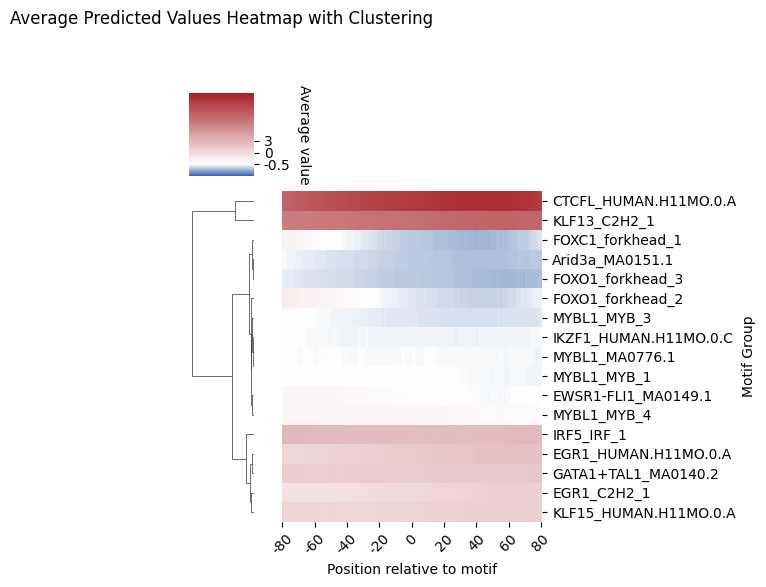

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Positions as integers for x labels
position_cols = [col for col in avg_diff.columns if col != 'motif_group']
positions = np.array(list(map(int, position_cols)))
xticks_positions = np.arange(-80, 81, 20)
xticks_indices = [np.where(positions == pos)[0][0] for pos in xticks_positions if pos in positions]

# Custom colormap with white at 0
from matplotlib.colors import LinearSegmentedColormap

vmin, vmax = -0.5, 3
white_pos = -vmin / (vmax - vmin)  # 0 maps to white

# Make a colormap with explicit positions
colors = [
    (0.0, "#3361A5"),        # dark blue at min
    (white_pos, "#ffffff"),  # white at 0
    (1.0, "#A52126")         # dark red at max
]

cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", colors, N=256)


# Full data matrix
data_matrix = avg_diff.set_index('motif_group')[position_cols]

# Plot clustermap with row clustering
g = sns.clustermap(
    data_matrix,
    cmap=cmap,
    row_cluster=True,
    col_cluster=False,        # keep positions in original order
    figsize=(6, max(6, len(data_matrix) * 0.75 * 0.15)),
    yticklabels=True,
    xticklabels=False,
    vmin=vmin,
    vmax=vmax,
)

# Set x-axis ticks manually
g.ax_heatmap.set_xticks(xticks_indices)
g.ax_heatmap.set_xticklabels(xticks_positions, rotation=45)

g.ax_heatmap.set_xlabel("Position relative to motif")
g.ax_heatmap.set_ylabel("Motif Group")
plt.title("Average Predicted Values Heatmap with Clustering", pad=50)

# Adjust colorbar ticks to show min, zero, max
cbar = g.cax
cbar_ticks = [-0.5, 0, 3]
g.cax.set_yticks([0, 0.5, 1])  # placeholder, will be adjusted by colorbar
g.cax.set_yticklabels(cbar_ticks)
g.cax.set_ylabel("Average value", rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/knockout_clustermap_full.png",
    dpi=600
)
plt.show()

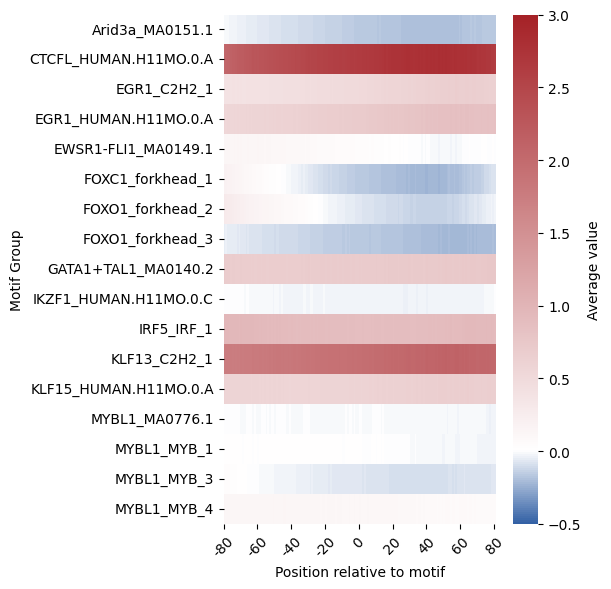

In [13]:
# Sort motifs alphabetically by motif_group
sorted_data = avg_diff.sort_values(by="motif_group")
sorted_labels = list(sorted_data['motif_group'])

plt.figure(figsize=(6, fig_height))

sns.heatmap(
    sorted_data[position_cols],
    cmap=cmap,
    yticklabels=sorted_labels,
    xticklabels=False,
    cbar_kws={"label": "Average value"},
    vmin=-0.5,
    vmax=3
)

plt.xlabel("Position relative to motif")
plt.ylabel("Motif Group")
# plt.title("Average Predicted Values Heatmap")

# Set x ticks and labels
plt.xticks(xticks_indices, xticks_positions, rotation=45)

plt.tight_layout()
plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/knockout_heatmap_alphabetical.svg",
   format="svg"
)
plt.show()


#### I want to check what normalizing each row looks like

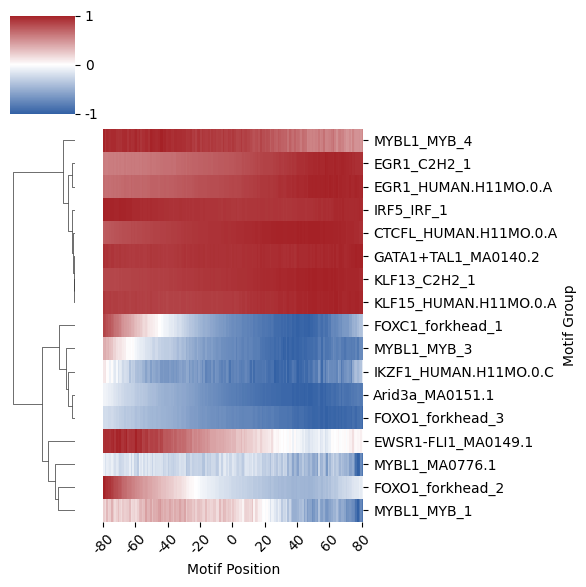

In [14]:
# Row-wise normalization: divide by max absolute value of each row
data_matrix_scaled = data_matrix.div(data_matrix.abs().max(axis=1), axis=0)

# Now values are in [-1, 1]
vmin, vmax = -1, 1

colors = [
    (0.0, "#3361A5"),   # dark blue at -1
    (0.5, "#ffffff"),   # white at 0
    (1.0, "#A52126")    # dark red at +1
]
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", colors, N=256)

# Plot clustermap with row clustering
g = sns.clustermap(
    data_matrix_scaled,
    cmap=cmap,
    row_cluster=True,
    col_cluster=False,
    figsize=(6, max(6, len(data_matrix_scaled) * 0.75 * 0.15)),
    yticklabels=True,
    xticklabels=False,
    vmin=vmin,
    vmax=vmax,
)

# X-axis ticks
g.ax_heatmap.set_xticks(xticks_indices)
g.ax_heatmap.set_xticklabels(xticks_positions, rotation=45)

g.ax_heatmap.set_xlabel("Motif Position")
g.ax_heatmap.set_ylabel("Motif Group")
# plt.title("Row-Normalized Predicted Values Heatmap (signed)", pad=50)

# Colorbar
cbar = g.cax
cbar_ticks = [-1, 0, 1]
cbar.set_yticks(cbar_ticks)       # positions in data scale
cbar.set_yticklabels(cbar_ticks)
# g.cax.set_ylabel("Scaled value (row-wise, signed)", rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/human/knockout_clustermap_row_scaled_signed.png",
    dpi=600
)
plt.show()
